<table>
        <td>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="400"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue"> Conceptos Machine Learning </p> Modelos Clasificación  </FONT>         </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Diplomado Machine Learning </p></tp>
            <tp><p style="font-size:115%;text-align:center">2026-1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

# <FONT SIZE=5 COLOR="purple"> Objetivos de la Sesión </FONT>

En esta sección revisaremos:

- Exploración de Datos

- Modelos de clasificación

- Evaluación de los modelos

- Optimización de Hiperparámetros

Iniciaremos cargando las librerías

In [ ]:
# Manipulación de data.frames
import pandas as pd
import numpy as np

# Librerías para Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split

# Para preprocesamiento
from sklearn.preprocessing      import StandardScaler, MinMaxScaler
from sklearn.preprocessing      import LabelEncoder, OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline

# Para modelos de clasificación
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.svm                import SVC
from sklearn.ensemble           import RandomForestClassifier

# Métricas de evaluación
from sklearn.metrics            import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics            import accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics           import specificity_score

# para hacer la curva ROC
from sklearn.metrics            import roc_auc_score
from sklearn.metrics            import roc_curve

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV

import time

# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

# <FONT SIZE=5 COLOR="purple"> Caso Tarjetas de Crédito </FONT>

***Objetivo del ejercicio***. Aplicar el modelo de clasificación ***KNN-Reglog-Árboles*** para determinar cuando se aprueba a un cliente una tarjeta de crédito o no, dependiendo de las otras variables.

***Contexto de los datos***

Este ejercicio se basa en un conjunto de datos que se publicó originalmente junto con la quinta edición del libro *Análisis Econométrico* de William Greene.

Este libro tiene datos de tarjetas de crédito que se componen de una variable objetivo que es de naturaleza binaria (1 si se aprueba la solicitud de tarjeta de crédito, 0 si no) y algunas variables independientes sobre la demografía y el historial crediticio de los titulares de tarjetas de crédito.

Los datos para este trabajo están en *kaggle* en la siguiente *url*.

https://www.kaggle.com/datasets/dansbecker/aer-credit-card-data?select=AER_credit_card_data.csv

Sin embargo, se anexan los datos como ***credict3*** y este trabajo se va a desarrollar con esta base.

```python
url = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/credit_card.csv"
```

Cada fila representa una solicitud de tarjeta de crédito, cada columna contiene los atributos del solicitante:

- *tarjeta*: variable ficticia, 1 si se aprueba la solicitud de tarjeta de crédito, 0 si no

- *informes*: número de informes despectivos importantes.

- *edad*: Edad n años más doceavos de un año.

- *ingreso*: ingreso anual (dividido por 10,000).

- *participación*: relación entre el gasto mensual de la tarjeta de crédito y el ingreso anual.

- *gasto*: gasto medio mensual con tarjeta de crédito.

- *propietario*: 1 si es dueño de su casa, 0 si alquila.

- *selfemp*: 1 si es autónomo, 0 si no.

- *dependientes*: 1 + número de dependientes.

- *meses*: Meses viviendo en la dirección actual.

- *majorcards*: número de las principales tarjetas de crédito que se tienen.

- activo: Número de cuentas de crédito activas.

Según Greene (2003, p. 952) los dependientes equivalen a 1 + número de dependientes. Eso se describe arriba. Los autores del paquete “AER” en R creen que es el número de dependientes.

Algunas precisiones sobre las variables

- *Los informes promedio* (es decir, el número promedio de informes despectivos importantes) de los solicitantes que fueron aprobados es menor que el de los solicitantes que no fueron aprobados.

- *El ingreso promedio* (es decir, el ingreso anual promedio dividido por 10,000) de los solicitantes que fueron aprobados es más alto que el de los solicitantes que no fueron aprobados.

- *La participación promedio* (es decir, la relación promedio entre el gasto mensual de la tarjeta de crédito y el ingreso anual) de los solicitantes que fueron aprobados es más alta que la de los solicitantes que no fueron aprobados.

- *El gasto promedio* (es decir, el gasto mensual promedio con tarjeta de crédito) de los solicitantes que fueron aprobados es más alto que el de los solicitantes que no fueron aprobados.

- *El promedio de dependientes*(es decir, el número promedio de dependientes) de los solicitantes que fueron aprobados es menor que el de los solicitantes que no fueron aprobados.

- *El promedio de tarjetas principales (es decir, el número promedio de las principales tarjetas de crédito) de los solicitantes que fueron aprobados es más alto que el de los solicitantes que no fueron aprobados.


## <FONT SIZE=5 COLOR="purple"> 1. Carga y limpieza de los datos </FONT>

### <FONT SIZE=4 COLOR="blue"> 1.1 Carga y exploración rápida de los datos</FONT>

In [52]:
# cargar los datos que están la dirección del github
url = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/credit_card2.csv"
credito = pd.read_csv(url,  na_values=[" "])

na.values : si hay espacios (blanco) lo identifica como dato faltante NaN (NA)

In [53]:
# revisamos los primeros datos
credito.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,yes,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,yes,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


In [54]:
# nombres de las variables
credito.columns

Index(['card', 'reports', 'age', 'income', 'share', 'expenditure', 'owner',
       'selfemp', 'dependents', 'months', 'majorcards', 'active'],
      dtype='object')

In [55]:
# tamaño de los datos
credito.shape

(1319, 12)

In [56]:
# información de los datos
credito.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   card         1319 non-null   object 
 1   reports      1319 non-null   int64  
 2   age          1319 non-null   float64
 3   income       1319 non-null   float64
 4   share        1319 non-null   float64
 5   expenditure  1319 non-null   float64
 6   owner        1319 non-null   object 
 7   selfemp      1319 non-null   object 
 8   dependents   1319 non-null   int64  
 9   months       1319 non-null   int64  
 10  majorcards   1319 non-null   int64  
 11  active       1319 non-null   int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 123.8+ KB


In [57]:
credito.describe()

,reports,age,income,share,expenditure,dependents,months,majorcards,active
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,0.456406,33.213103,3.365376,0.068732,185.057071,0.993935,55.267627,0.817286,6.996967
std,1.345267,10.142783,1.693902,0.094656,272.218917,1.247745,66.271746,0.386579,6.305812
min,0.000000,0.166667,0.210000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,25.416670,2.243750,0.002316,4.583333,0.000000,12.000000,1.000000,2.000000
50%,0.000000,31.250000,2.900000,0.038827,101.298300,1.000000,30.000000,1.000000,6.000000
75%,0.000000,39.416670,4.000000,0.093617,249.035800,2.000000,72.000000,1.000000,11.000000
max,14.000000,83.500000,13.500000,0.906320,3099.505000,6.000000,540.000000,1.000000,46.000000


A continuación vamos a hacer algunos elementos de limpieza

- Organizar la variable card

- Organizar la variable edad

- Tener en cuenta que hay variables categóricas: owner , selftemp

<FONT SIZE=4 COLOR="red"> Organizar la Variable card </FONT>

In [58]:
credito["card"]

,card
0,yes
1,yes
2,yes
3,yes
4,yes
...,...
1314,yes
1315,no
1316,yes
1317,yes


In [59]:
# veamos la variable card (que es objetivo)
credito["card"].unique()

array(['yes', 'no', 'Yes', 'No'], dtype=object)

Vemos problema con esta variable porque aparecen varias categorias. Debemos unificarlas y convertir en 1  y 0

In [60]:
# transformar las categorias yes y YES en 1
credito.card = credito.card.replace({"yes": 1, "Yes": 1, "no": 0, "No": 0})

Veamos que si funciona

In [61]:
credito.card.value_counts()

,count
card,
1,1023
0,296


Observamos que los datos están desbalanceados. Es importante tenerlo en cuenta.

In [62]:
# revisamos los valores de la variable card
# credit.card // credit["card"]
credito.card.value_counts()

,count
card,
1,1023
0,296


<FONT SIZE=4 COLOR="red"> Organizar la Variable Edad</FONT>

In [63]:
credito.describe()

,card,reports,age,income,share,expenditure,dependents,months,majorcards,active
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,0.775588,0.456406,33.213103,3.365376,0.068732,185.057071,0.993935,55.267627,0.817286,6.996967
std,0.417353,1.345267,10.142783,1.693902,0.094656,272.218917,1.247745,66.271746,0.386579,6.305812
min,0.000000,0.000000,0.166667,0.210000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,25.416670,2.243750,0.002316,4.583333,0.000000,12.000000,1.000000,2.000000
50%,1.000000,0.000000,31.250000,2.900000,0.038827,101.298300,1.000000,30.000000,1.000000,6.000000
75%,1.000000,0.000000,39.416670,4.000000,0.093617,249.035800,2.000000,72.000000,1.000000,11.000000
max,1.000000,14.000000,83.500000,13.500000,0.906320,3099.505000,6.000000,540.000000,1.000000,46.000000


In [64]:
# vamos a filtrar por edad mayor o igual a 18
credito = credito[credito.age >= 18]

In [65]:
credito.age.describe()

,age
count,1312.000000
mean,33.387386
std,9.884200
min,18.166670
25%,25.416670
50%,31.291665
75%,39.416670
max,83.500000


<FONT SIZE=4 COLOR="red"> Separemos la variables categóricas y numéricas </FONT>

In [66]:
credito.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1312 entries, 0 to 1318
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   card         1312 non-null   int64  
 1   reports      1312 non-null   int64  
 2   age          1312 non-null   float64
 3   income       1312 non-null   float64
 4   share        1312 non-null   float64
 5   expenditure  1312 non-null   float64
 6   owner        1312 non-null   object 
 7   selfemp      1312 non-null   object 
 8   dependents   1312 non-null   int64  
 9   months       1312 non-null   int64  
 10  majorcards   1312 non-null   int64  
 11  active       1312 non-null   int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 133.2+ KB


In [67]:
credito.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,1,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,1,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,1,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,1,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


En este ejemplo debemos tener en cuenta que hay dos tipos de variables.

- Continuas (numéricas)

- Categóricas (atributos)

In [68]:
# nombre de las columnas
credito.columns

Index(['card', 'reports', 'age', 'income', 'share', 'expenditure', 'owner',
       'selfemp', 'dependents', 'months', 'majorcards', 'active'],
      dtype='object')

In [69]:
# variables numéricas de predicción
variables_num = credito.drop(["card","owner","selfemp"], axis =1).columns
variables_num

Index(['reports', 'age', 'income', 'share', 'expenditure', 'dependents',
       'months', 'majorcards', 'active'],
      dtype='object')

In [70]:
# variables categóricas de predicción (yes/no)
variables_cat = ["owner", "selfemp"]
variables_cat

['owner', 'selfemp']

Ahora vamos a aplicar los modelos. Para ellos vamos a

- Definir las variables

- Separa en entrenamiento y prueba

- Escalar los datos

## <FONT SIZE=5 COLOR="purple"> 2. Aplicación de los Modelos </FONT>

Antes de entrenar los modelos, vamos a

- Definir las variables

- Separar en entrenamiento y prueba

- Escalar los datos

In [71]:
credito.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,1,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,1,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,1,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,1,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


In [72]:
# 1. Dividir en dos conjuntos
# las variables predictoras
X = credito.drop("card", axis=1) # axis=1 indicar el proceso por columnas
# la variable objetivo
y = credito["card"]

# 2. conjunto de entrenamiento y de prueba
X_train, X_test, y_train, y_test = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    stratify=y,               # estratificamos con respecto a y (asegura que se mantenga la proporción de clases en y)
                                                    random_state = 0,         # semilla para que al ejecutar siempre de igual
                                                    test_size = 0.3)          # tamaño del conjunto de prueba

# 3. Definimos el preprocesador de escalamiento
preprocessor_1 = ColumnTransformer(transformers=[
    ('num', StandardScaler(), variables_num),
    ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), variables_cat)   #passthrough si no queremos hacer nada
])

preprocessor_2 = ColumnTransformer(transformers=[
    ('num', "passthrough", variables_num),
    ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), variables_cat)   #passthrough si no queremos hacer nada
])

Usamos el *ColumnsTransformer* ya que vamos a escalar las variables numéricas y las variables categóricas las dejaremos quietas.

In [73]:
credito.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,1,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,1,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,1,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,1,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


In [74]:
# MODELO_1: VECINOS MÁS CERCANOS
modelo_knn = Pipeline(steps=[
      ('preprocessor', preprocessor_1),
      ('modelo_knn', KNeighborsClassifier())
      ])
# entrenamos el modelo
modelo_knn.fit(X_train,y_train)

# MODELO_2: REGRESIÓN LOGÍSTICA
modelo_log = Pipeline(steps=[
      ('preprocessor', preprocessor_1),
      ('modelo_log', LogisticRegression())
      ])
# entrenamos el modelo
modelo_log.fit(X_train,y_train)

# # MODELO_3: ÁRBOLES DE DECISIÓN
modelo_tree = Pipeline(steps=[
      ('preprocessor', preprocessor_2),
      ('modelo_tree', DecisionTreeClassifier())
      ])
# entrenamos el modelo
modelo_tree.fit(X_train,y_train)

# MODELO_4 : MAQUINAS DE SOPORTE
modelo_svc = Pipeline(steps=[
      ('preprocessor', preprocessor_1),
      ('modelo_svc', SVC())
      ])
# entrenamos el modelo
modelo_svc.fit(X_train,y_train)

# MODELO_5 : RANDOM FOREST
modelo_rf = Pipeline(steps=[
      ('preprocessor', preprocessor_2),
      ('modelo_rf', RandomForestClassifier())
      ])
# entrenamos el modelo
modelo_rf.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['reports', 'age', 'income', 'share', 'expenditure', 'dependents',
       'months', 'majorcards', 'active'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['owner', 'selfemp'])])),
                ('modelo_rf', RandomForestClassifier())])

## <FONT SIZE=5 COLOR="purple"> 3. Evaluar los modelos </FONT>

In [75]:
def evaluacion_modelo(modelo, X_train, y_train, X_test, y_test, nombre_modelo = "modelo",graficar = True):
  # definir las predicciones en conjuntos de train y test
  y_pred_train = modelo.predict(X_train)
  y_pred_test  = modelo.predict(X_test)
  # matrices de confusión
  if graficar :
    # Calcular matrices de confusión
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test = confusion_matrix(y_test, y_pred_test)
    # ejes para gráficas
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # matriz de confusión en train
    sns.heatmap(pd.DataFrame(cm_train),                # data.frame
                  annot=True,                          # colocar números de las cajitas
                  annot_kws = {'size':20},             # tamaño de la letra
                  cmap="YlOrRd",                       # color de la letra 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu'
                  fmt='g',                             # para que salgan los número no : notación científica
                  ax=axes[0])
    axes[0].set_title(f'Matriz de Confusión - Train-{nombre_modelo}', fontsize=14)
    axes[0].set_xlabel('Predicciones')
    axes[0].set_ylabel('Valores Reales')
    # matriz de confusión en test
    sns.heatmap(pd.DataFrame(cm_test),
              annot=True,
              fmt='g',
              cmap='YlOrRd',
              annot_kws={'size':16},
              ax=axes[1])
    axes[1].set_title(f'Matriz de Confusión - Test-{nombre_modelo}', fontsize=14)
    axes[1].set_xlabel('Predicciones')
    axes[1].set_ylabel('Valores Reales')
    plt.tight_layout()
    plt.show()
  # metricas en train
  metrics=["accuracy", "recall" , "specificity", "precision", "f1"]
  # valores
  values_train = [accuracy_score(y_train,y_pred_train),
          recall_score(y_train,y_pred_train),
          specificity_score(y_train,y_pred_train),
          precision_score(y_train,y_pred_train),
          f1_score(y_train,y_pred_train)]
  values_test = [accuracy_score(y_test,y_pred_test),
          recall_score(y_test,y_pred_test),
          specificity_score(y_test,y_pred_test),
          precision_score(y_test,y_pred_test),
          f1_score(y_test,y_pred_test)]

  df = pd.DataFrame({f"{nombre_modelo}_train" : values_train,
                      f"{nombre_modelo}_test" : values_test}, index = metrics)
  return df

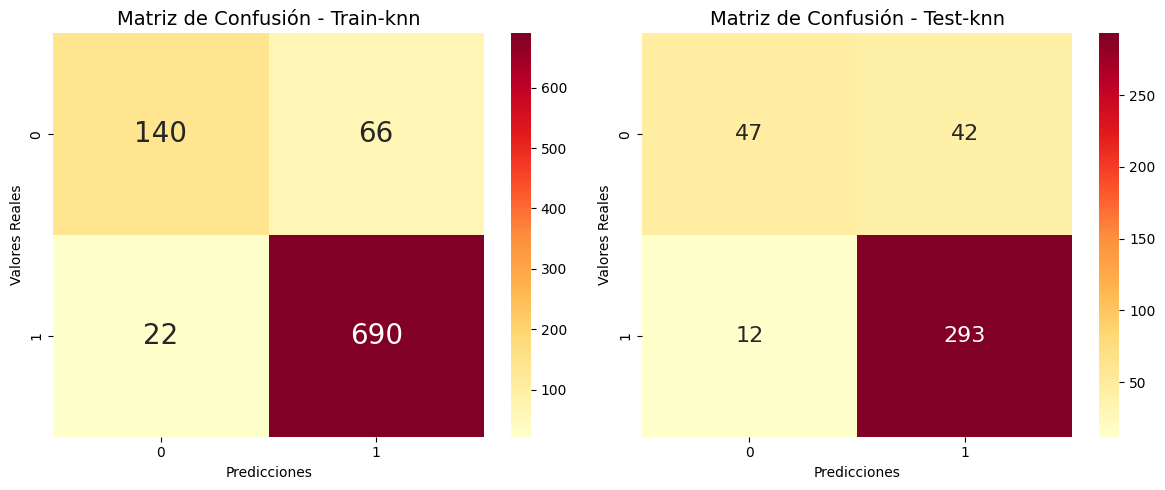

,knn_train,knn_test
accuracy,0.904139,0.862944
recall,0.969101,0.960656
specificity,0.679612,0.528090
precision,0.912698,0.874627
f1,0.940054,0.915625


In [76]:
# evaluación de knn
metricas_knn = evaluacion_modelo(modelo_knn, X_train, y_train, X_test, y_test, nombre_modelo="knn", graficar=True)
metricas_knn

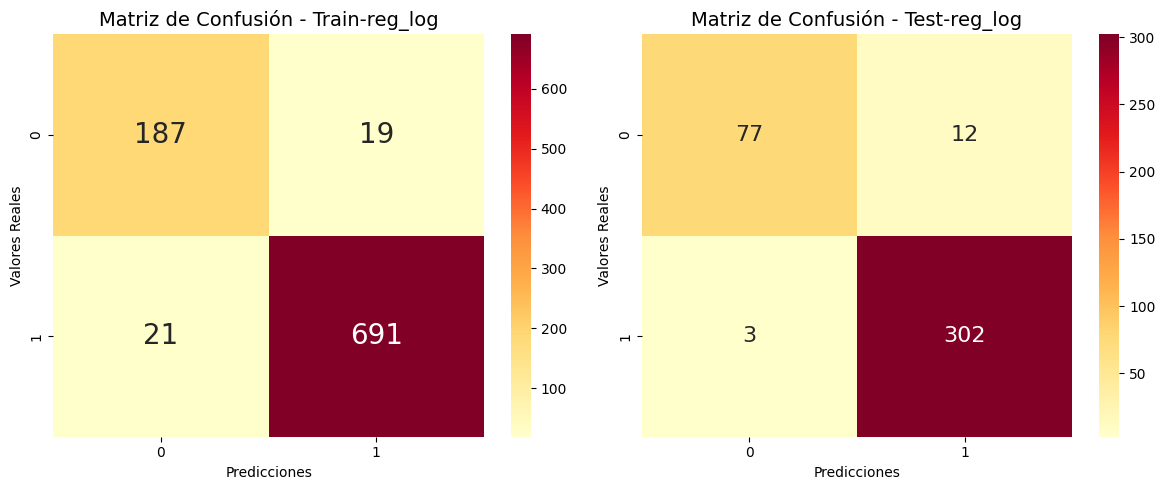

,reg_log_train,reg_log_test
accuracy,0.956427,0.961929
recall,0.970506,0.990164
specificity,0.907767,0.865169
precision,0.973239,0.961783
f1,0.971871,0.975767


In [77]:
metricas_log = evaluacion_modelo(modelo_log, X_train, y_train, X_test, y_test, nombre_modelo="reg_log", graficar=True)
metricas_log

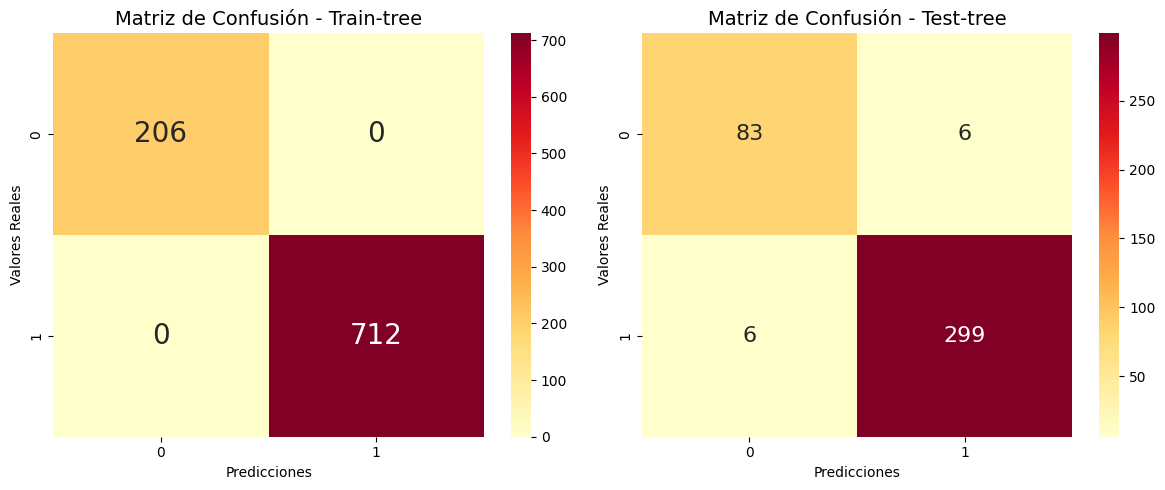

,tree_train,tree_test
accuracy,1.0,0.969543
recall,1.0,0.980328
specificity,1.0,0.932584
precision,1.0,0.980328
f1,1.0,0.980328


In [78]:
metricas_tree = evaluacion_modelo(modelo_tree, X_train, y_train, X_test, y_test, nombre_modelo="tree", graficar=True)
metricas_tree

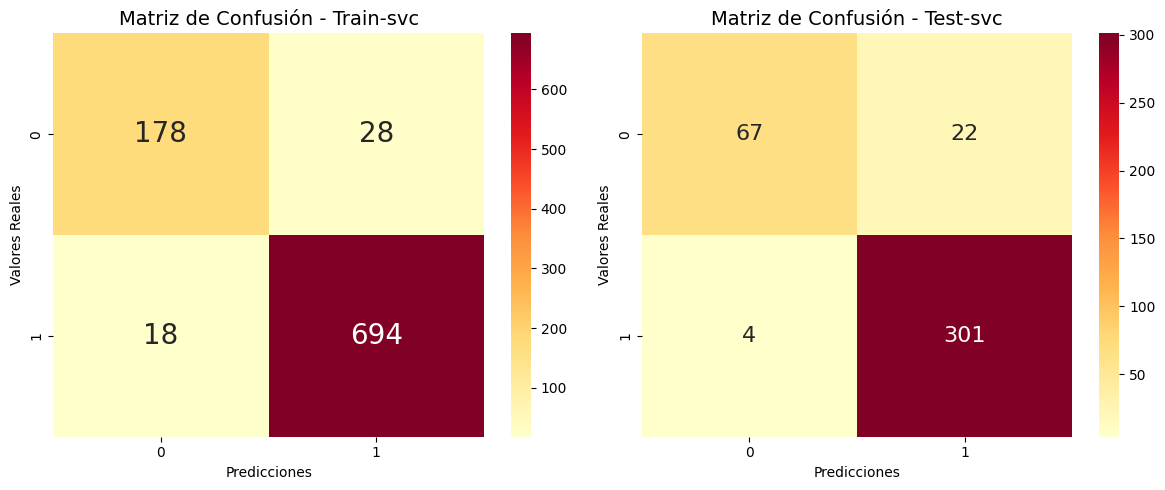

,svc_train,svc_test
accuracy,0.949891,0.934010
recall,0.974719,0.986885
specificity,0.864078,0.752809
precision,0.961219,0.931889
f1,0.967922,0.958599


In [79]:
metricas_svc = evaluacion_modelo(modelo_svc, X_train, y_train, X_test, y_test, nombre_modelo="svc", graficar=True)
metricas_svc

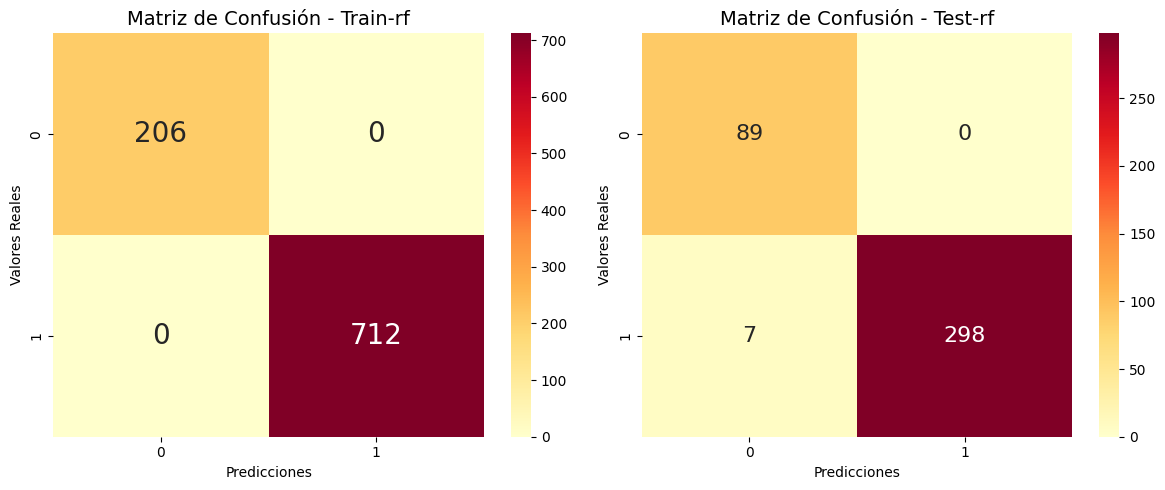

,rf_train,rf_test
accuracy,1.0,0.982234
recall,1.0,0.977049
specificity,1.0,1.000000
precision,1.0,1.000000
f1,1.0,0.988391


In [80]:
metricas_rf = evaluacion_modelo(modelo_rf, X_train, y_train, X_test, y_test, nombre_modelo="rf", graficar=True)
metricas_rf

Ahora, vamos a pegar todo en un solo dataframe

In [81]:
# pegar los eva en un solo dataframe
metricas_total = pd.concat([metricas_knn, metricas_log, metricas_tree, metricas_svc, metricas_rf], axis = 1)
metricas_total

,knn_train,knn_test,reg_log_train,reg_log_test,tree_train,tree_test,svc_train,svc_test,rf_train,rf_test
accuracy,0.904139,0.862944,0.956427,0.961929,1.0,0.969543,0.949891,0.934010,1.0,0.982234
recall,0.969101,0.960656,0.970506,0.990164,1.0,0.980328,0.974719,0.986885,1.0,0.977049
specificity,0.679612,0.528090,0.907767,0.865169,1.0,0.932584,0.864078,0.752809,1.0,1.000000
precision,0.912698,0.874627,0.973239,0.961783,1.0,0.980328,0.961219,0.931889,1.0,1.000000
f1,0.940054,0.915625,0.971871,0.975767,1.0,0.980328,0.967922,0.958599,1.0,0.988391


# <FONT SIZE=5 COLOR="purple"> 3. Curva ROC y AUC </FONT>

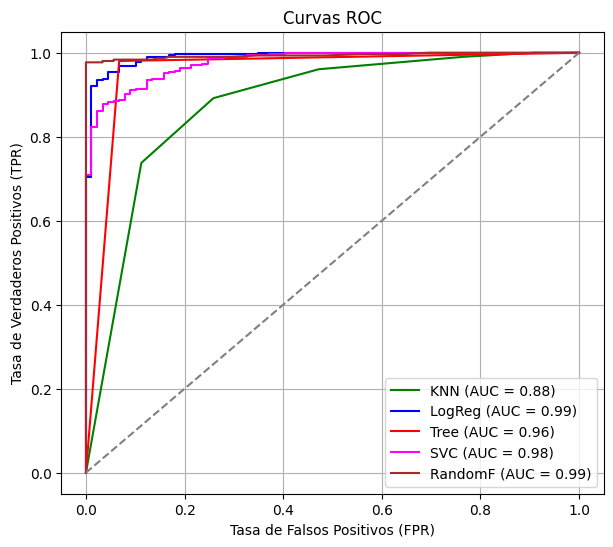

In [82]:
# cálculo de los elementos
# Curva ROC

fpr_test_knn, tpr_test_knn, _ = roc_curve(y_test, modelo_knn.predict_proba(X_test)[:,1])
fpr_test_log, tpr_test_log, _ = roc_curve(y_test, modelo_log.predict_proba(X_test)[:,1])
fpr_test_tree, tpr_test_tree, _ = roc_curve(y_test, modelo_tree.predict_proba(X_test)[:,1])
fpr_test_svc, tpr_test_svc, _ = roc_curve(y_test, modelo_svc.decision_function(X_test))
fpr_test_rf, tpr_test_rf, _ = roc_curve(y_test, modelo_rf.predict_proba(X_test)[:,1])

# AUC
auc_test_knn = roc_auc_score(y_test, modelo_knn.predict_proba(X_test)[:,1])
auc_test_log = roc_auc_score(y_test, modelo_log.predict_proba(X_test)[:,1])
auc_test_tree = roc_auc_score(y_test, modelo_tree.predict_proba(X_test)[:,1])
auc_test_svc = roc_auc_score(y_test, modelo_svc.decision_function(X_test))
auc_test_rf = roc_auc_score(y_test, modelo_rf.predict_proba(X_test)[:,1])


# Gráfica curva ROC
plt.figure(figsize=(7,6))
plt.plot(fpr_test_knn, tpr_test_knn, color='green', label=f'KNN (AUC = {auc_test_knn:.2f})')
plt.plot(fpr_test_log, tpr_test_log, color='blue', label=f'LogReg (AUC = {auc_test_log:.2f})')
plt.plot(fpr_test_tree, tpr_test_tree, color='red', label=f'Tree (AUC = {auc_test_tree:.2f})')
plt.plot(fpr_test_svc, tpr_test_svc, color='magenta', label=f'SVC (AUC = {auc_test_svc:.2f})')
plt.plot(fpr_test_rf, tpr_test_rf, color='brown', label=f'RandomF (AUC = {auc_test_rf:.2f})')

# Línea diagonal (azar)
plt.plot([0,1], [0,1], color='gray', linestyle='--')

# Detalles del gráfico
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curvas ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [90]:
X_new_1 = [0,	38,	4.6,	0.03,	125.3,"yes","no",	2,	48,	1,	8]
X_new_2 = [1, 25, 1.8 ,0.0006, 0.0, "no","no", 2, 7, 2, 4]
X_new_3 = [0, 22, 3.8, 0.0003,0 ,"no","yes", 1, 12, 2, 4]


In [93]:
df = pd.DataFrame([X_new_1,X_new_2,X_new_3], columns=X_train.columns)
pred = modelo_log.predict(df)
pred

array([1, 0, 1])

In [94]:
df["prediccion"] = pred

In [95]:
df

,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active,prediccion
0,0,38,4.6,0.0300,125.3,yes,no,2,48,1,8,1
1,1,25,1.8,0.0006,0.0,no,no,2,7,2,4,0
2,0,22,3.8,0.0003,0.0,no,yes,1,12,2,4,1
